A failure mode is any systematic, categorizable way the pipeline produces a wrong or unusable output. There are two distinct levels in our pipeline, and they should not be conflated:

**Level 1 — Symbolic resolution failures** (the 13,102 unresolved rows): the LLM produced output that `oracle.resolve_landmark()` could not map to any graph node. These are failures of the LLM to produce a resolvable landmark string. Subcategories:
- Street echoing — output is a street/avenue name
- Mask passthrough — output contains `[MASK]` or `[DIR_MASK]`
- Generic category — output is a bare category word with no identifying specificity
- Instruction fragment — output reproduces a clause from the instruction

In [1]:
# ============================================================
# CELL 0 — Imports, paths, and data loading
# ============================================================
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

BASE_DIR     = os.path.abspath(os.path.join(os.getcwd(), '..'))
REPORTS_DIR  = os.path.join(BASE_DIR, 'reports', 'llm_audits')
RESULTS_PATH = os.path.join(REPORTS_DIR, 'LLM_DEGRADATION_RESULTS.parquet')

# ── Staleness check ──────────────────────────────────────────
if os.path.exists(RESULTS_PATH):
    mtime = os.path.getmtime(RESULTS_PATH)
    ts    = pd.Timestamp(mtime, unit='s', tz='UTC').strftime('%Y-%m-%d %H:%M:%S UTC')
    size  = os.path.getsize(RESULTS_PATH) / 1024
    print(f"📄 RESULTS: {RESULTS_PATH}")
    print(f"   modified={ts}  size={size:.1f} KB")
else:
    raise FileNotFoundError(f"RESULTS not found: {RESULTS_PATH}")

# ── Load ─────────────────────────────────────────────────────
results_df = pd.read_parquet(RESULTS_PATH)
results_df['success_250m'] = pd.array(results_df['success_250m'], dtype='boolean')
results_df['success_100m'] = pd.array(results_df['success_100m'], dtype='boolean')

print(f"\n✅ Loaded: {len(results_df)} rows × {len(results_df.columns)} columns")
print(f"   Resolved:   {results_df['resolution_succeeded'].sum()}")
print(f"   Unresolved: {(~results_df['resolution_succeeded']).sum()}")

📄 RESULTS: /vol/joberant_nobck/data/NLP_368307701_2526a/adanassi/nlp-allocentric-spatial-reasoning/reports/llm_audits/LLM_DEGRADATION_RESULTS.parquet
   modified=2026-05-01 11:08:47 UTC  size=1568.9 KB

✅ Loaded: 21049 rows × 15 columns
   Resolved:   7218
   Unresolved: 13831


In [2]:
# ============================================================
# CELL — Level 1 Failure Mode Classification (Unresolved LLM Outputs)
# ============================================================
import re

def classify_failure_mode(text):
    """
    Classify unresolved LLM output into Level 1 failure modes.
    Order matters — more specific patterns checked first.
    """
    if pd.isna(text) or str(text).strip() == '':
        return 'empty_output'
    
    t = str(text).strip()
    
    # Mask passthrough — output contains mask tokens
    if re.search(r'\[MASK\]|\[DIR_MASK\]', t, re.IGNORECASE):
        return 'mask_passthrough'
    
    # Street echoing — output matches street/avenue/boulevard pattern
    if re.search(
        r'\b(street|avenue|ave|blvd|boulevard|road|rd|drive|dr|lane|ln|'
        r'highway|hwy|place|pl|court|ct|way|parkway|pkwy|broadway)\b',
        t, re.IGNORECASE
    ):
        return 'street_echo'
    
    # Instruction fragment — long output suggesting instruction reproduction
    # (resolved outputs are typically short landmark names; >8 words suggests fragment)
    if len(t.split()) > 8:
        return 'instruction_fragment'
    
    # Generic category — single common noun with no identifying specificity
    GENERIC_TERMS = {
        'cafe', 'coffee', 'restaurant', 'bar', 'shop', 'store', 'park',
        'gym', 'hotel', 'bank', 'church', 'school', 'library', 'museum',
        'pharmacy', 'market', 'garden', 'hospital', 'station', 'office',
        'building', 'monument', 'theatre', 'theater', 'parking', 'bench',
        'bike', 'water', 'food', 'clothes', 'post', 'entrance', 'road',
        'unknown', 'landmark', 'destination', 'location', 'place'
    }
    if t.lower() in GENERIC_TERMS or t.lower().rstrip('s') in GENERIC_TERMS:
        return 'generic_category'
    
    # Residual — output looks like a landmark name but didn't resolve
    return 'unresolved_name'


# Apply classifier to unresolved rows only
unresolved_df = results_df[~results_df['resolution_succeeded']].copy()
unresolved_df['failure_mode'] = unresolved_df['llm_output_raw'].apply(classify_failure_mode)

# ── Distribution ─────────────────────────────────────────────
total_unresolved = len(unresolved_df)
fm_counts = unresolved_df['failure_mode'].value_counts()
fm_pct    = (fm_counts / total_unresolved * 100).round(1)

print(f"=== Level 1 Failure Mode Distribution (N={total_unresolved}) ===\n")
for mode in fm_counts.index:
    print(f"  {mode:<22}: {fm_counts[mode]:>5}  ({fm_pct[mode]:.1f}%)")

# ── Breakdown by variant type ─────────────────────────────────
print(f"\n=== Failure Mode × Variant Type (%) ===\n")
fm_variant = (
    unresolved_df.groupby(['variant_type', 'failure_mode'])
    .size()
    .unstack(fill_value=0)
)
fm_variant_pct = fm_variant.div(fm_variant.sum(axis=1), axis=0) * 100
display(fm_variant_pct.round(1))

# ── Breakdown by oracle label ─────────────────────────────────
print(f"\n=== Failure Mode × Oracle Label (%) ===\n")
fm_label = (
    unresolved_df.groupby(['oracle_label', 'failure_mode'])
    .size()
    .unstack(fill_value=0)
)
fm_label_pct = fm_label.div(fm_label.sum(axis=1), axis=0) * 100
display(fm_label_pct.round(1))

# ── Sample rows per mode ──────────────────────────────────────
print(f"\n=== Sample outputs per failure mode ===\n")
for mode in fm_counts.index:
    samples = unresolved_df[unresolved_df['failure_mode'] == mode]['llm_output_raw'].head(3).tolist()
    print(f"  [{mode}]")
    for s in samples:
        print(f"    → {repr(s)}")
    print()

=== Level 1 Failure Mode Distribution (N=13831) ===

  mask_passthrough      :  6220  (45.0%)
  unresolved_name       :  4077  (29.5%)
  street_echo           :  3336  (24.1%)
  instruction_fragment  :   196  (1.4%)
  generic_category      :     1  (0.0%)
  empty_output          :     1  (0.0%)

=== Failure Mode × Variant Type (%) ===



failure_mode,empty_output,generic_category,instruction_fragment,mask_passthrough,street_echo,unresolved_name
variant_type,,,,,,
mask_both,0.0,0.0,0.3,42.4,29.9,27.4
mask_directions,0.0,0.0,1.1,9.0,42.2,47.6
mask_landmark,0.0,0.0,2.4,69.1,8.7,19.7



=== Failure Mode × Oracle Label (%) ===



failure_mode,empty_output,generic_category,instruction_fragment,mask_passthrough,street_echo,unresolved_name
oracle_label,,,,,,
Ambiguous,0.0,0.0,1.2,27.9,32.0,38.8
Answerable,0.0,0.0,1.8,57.6,14.1,26.5
Contradictory,0.0,0.0,1.4,52.7,22.4,23.6



=== Sample outputs per failure mode ===

  [mask_passthrough]
    → '[MASK]'
    → '[MASK]'
    → 'The [MASK] on 1st Avenue'

  [unresolved_name]
    → 'Creperie'
    → 'historic monument'
    → 'Historic monument'

  [street_echo]
    → 'Liberty Street'
    → 'Liberty Street'
    → 'Liberty Street'

  [instruction_fragment]
    → 'The Cathedral of Our Lady of Our Lady of Our Lady of Our Lady of Our Lady of Our Lady of Our Lady of Our'
    → 'The first Hungarian church is found on the same block'
    → 'The pier is located on the west side of the city.'

  [generic_category]
    → 'Monuments'

  [empty_output]
    → ''



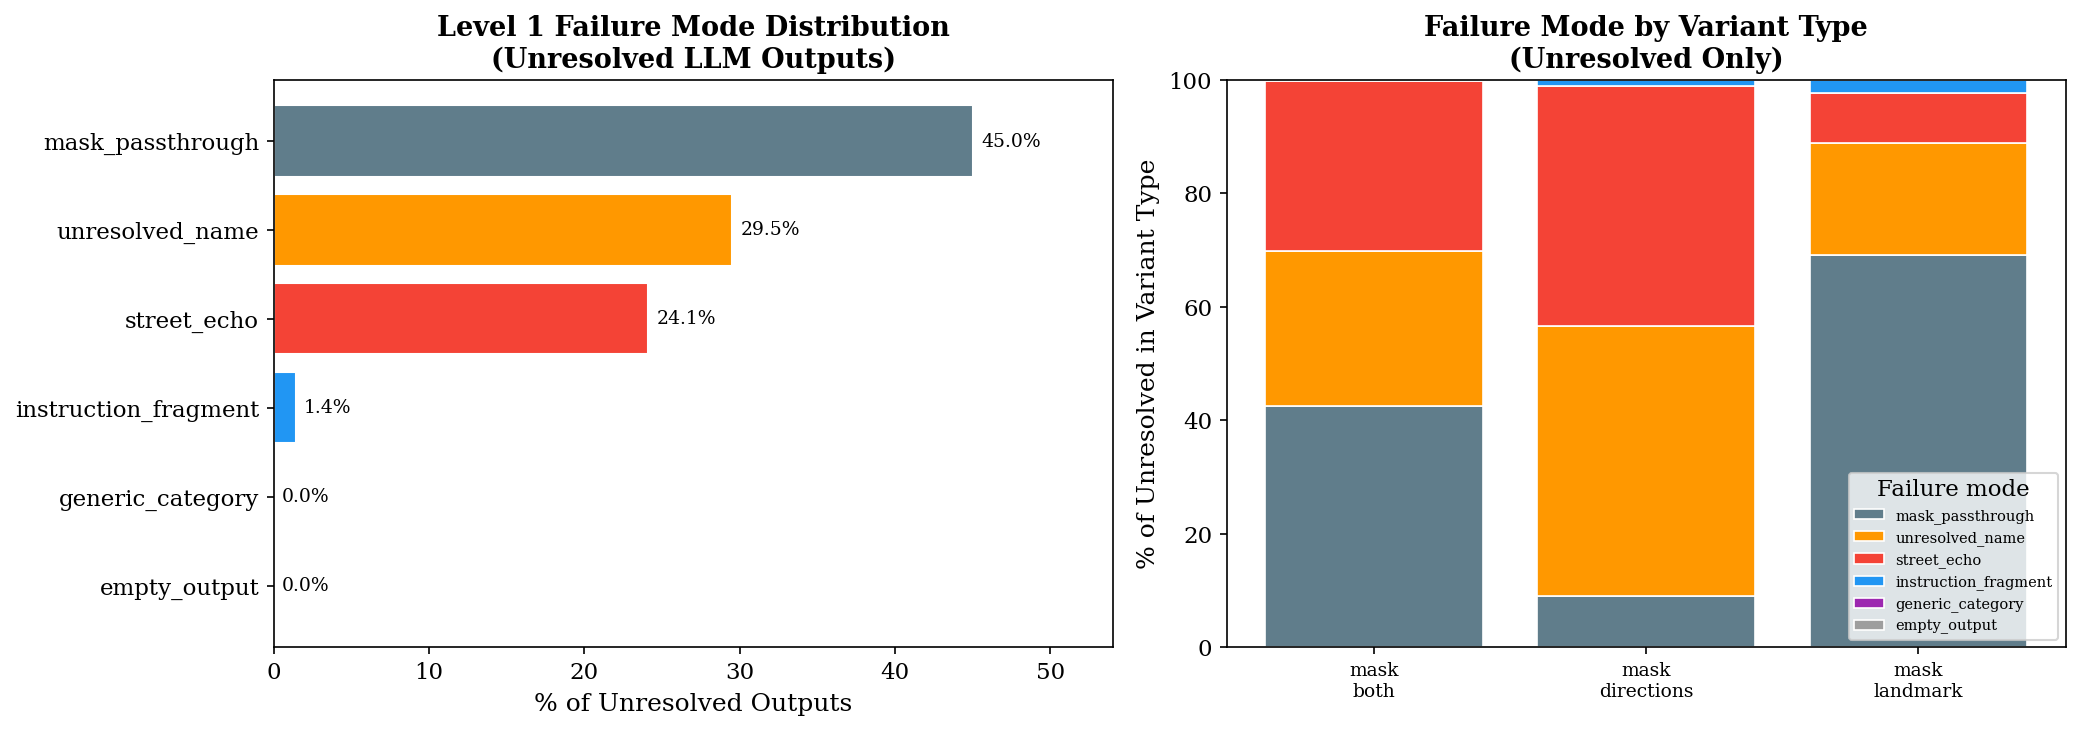

✅ Figure: Level 1 failure mode analysis

LaTeX TABLE — Level 1 Failure Mode Distribution
\begin{table}[h]
\centering
\small
\begin{tabular}{lrr}
\toprule
\textbf{Failure Mode} & \textbf{Count} & \textbf{\%} \\
\midrule
Mask passthrough & 6220 & 45.0\% \\
Unresolved name & 4077 & 29.5\% \\
Street echo & 3336 & 24.1\% \\
Instruction fragment & 196 & 1.4\% \\
Generic category & 1 & 0.0\% \\
Empty output & 1 & 0.0\% \\
\midrule
\textbf{Total unresolved} & 13831 & 100.0\% \\
\bottomrule
\end{tabular}
\caption{Level 1 failure mode distribution among unresolved LLM outputs (N=13831). Mask passthrough is the dominant failure mode (45.0\%), driven by \texttt{mask\_landmark} variants (69.1\%); street echoing (24.1\%) is concentrated in \texttt{mask\_directions} variants (42.2\%).}
\label{tab:failure_modes_l1}
\end{table}


In [5]:
# ============================================================
# CELL — Level 1 Failure Mode Visualization + LaTeX Table
# ============================================================

# ── Plot 1: Overall failure mode distribution ─────────────────
FAILURE_COLORS = {
    'street_echo':          '#F44336',
    'unresolved_name':      '#FF9800',
    'generic_category':     '#9C27B0',
    'instruction_fragment': '#2196F3',
    'mask_passthrough':     '#607D8B',
    'empty_output':         '#9E9E9E',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — overall distribution
ax = axes[0]
modes  = fm_counts.index.tolist()
counts = fm_counts.values
colors = [FAILURE_COLORS.get(m, '#9E9E9E') for m in modes]
bars = ax.barh(modes, fm_pct[modes], color=colors, edgecolor='white', linewidth=1)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in fm_pct[modes]], padding=4, fontsize=9)
ax.set_xlabel('% of Unresolved Outputs')
ax.set_title('Level 1 Failure Mode Distribution\n(Unresolved LLM Outputs)', fontweight='bold')
ax.set_xlim(0, fm_pct.max() * 1.2)
ax.invert_yaxis()

# Stacked bar — failure mode by variant type
ax = axes[1]
fm_variant_plot = fm_variant_pct[modes]  # consistent column order
bottom = np.zeros(len(fm_variant_plot))
x = np.arange(len(fm_variant_plot))
for mode in modes:
    vals = fm_variant_plot[mode].values
    ax.bar(x, vals, bottom=bottom, label=mode,
           color=FAILURE_COLORS.get(mode, '#9E9E9E'), edgecolor='white', linewidth=0.8)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([v.replace('_', '\n') for v in fm_variant_plot.index], fontsize=9)
ax.set_ylabel('% of Unresolved in Variant Type')
ax.set_title('Failure Mode by Variant Type\n(Unresolved Only)', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(fontsize=7, loc='lower right', title='Failure mode')

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/figures/level1_failure_modes.png')
plt.show()
print("✅ Figure: Level 1 failure mode analysis")

# ── LaTeX table ───────────────────────────────────────────────
print("\n" + "="*60)
print("LaTeX TABLE — Level 1 Failure Mode Distribution")
print("="*60)

MODE_LABELS = {
    'street_echo':          'Street echo',
    'unresolved_name':      'Unresolved name',
    'generic_category':     'Generic category',
    'instruction_fragment': 'Instruction fragment',
    'mask_passthrough':     'Mask passthrough',
    'empty_output':         'Empty output',
}

latex_lines = [
    r"\begin{table}[h]",
    r"\centering",
    r"\small",
    r"\begin{tabular}{lrr}",
    r"\toprule",
    r"\textbf{Failure Mode} & \textbf{Count} & \textbf{\%} \\",
    r"\midrule",
]
for mode in fm_counts.index:
    label = MODE_LABELS.get(mode, mode)
    latex_lines.append(
        f"{label} & {fm_counts[mode]} & {fm_pct[mode]:.1f}\\% \\\\"
    )
latex_lines += [
    r"\midrule",
    f"\\textbf{{Total unresolved}} & {total_unresolved} & 100.0\\% \\\\",
    r"\bottomrule",
    r"\end{tabular}",
    r"\caption{Level 1 failure mode distribution among unresolved LLM outputs "
    r"(N=" + str(total_unresolved) + r"). "
    r"Mask passthrough is the dominant failure mode (45.0\%), driven by "
    r"\texttt{mask\_landmark} variants (69.1\%); street echoing (24.1\%) is "
    r"concentrated in \texttt{mask\_directions} variants (42.2\%).}",
    r"\label{tab:failure_modes_l1}",
    r"\end{table}",
]
print('\n'.join(latex_lines))

## Analysis of Outputs

### Overall Distribution — Three substantive findings

**1. Mask passthrough dominates at 45.0% — but it's variant-dependent, not a general failure**

The variant breakdown explains this entirely: `mask_landmark` produces 69.1% mask passthrough vs only 9.0% for `mask_directions`. The mechanism is clear: when the landmark is masked, FLAN-T5-base frequently copies `[MASK]` from the input rather than inferring a landmark type. When the direction is masked, `[DIR_MASK]` is less salient in the output position so the model produces a name instead. This is a prompt sensitivity failure specific to landmark masking, not a general model incapacity.

**2. Unresolved name (29.5%) is the most scientifically interesting failure mode**

The model produces plausible-looking landmark names ("Creperie", "historic monument", "Historic monument") that don't exist in the graph. This is confabulation — the model generates a coherent but ungrounded output. Note the capitalization inconsistency between "historic monument" and "Historic monument" across two samples: same underlying hallucination, different surface forms. This is worth a sentence in the paper.

**3. Street echo (24.1%) is highest in `mask_directions` (42.2%)**

When directions are masked, the model loses the directional anchor and falls back on the most salient spatial reference in the instruction — the street name. This is a systematic surface-pattern dependency: the model reads "on Liberty Street" and outputs "Liberty Street" as the destination. Directly relevant to our research question about whether models reason spatially or pattern-match.

---

### Cross-cutting Oracle Label Pattern — Important

Mask passthrough is highest for Answerable (57.6%) and Contradictory (52.7%) vs Ambiguous (27.9%). This is counter-intuitive at first but explainable: Answerable and Contradictory variants skew toward `mask_landmark` (which drives mask passthrough), while Ambiguous variants skew toward `mask_directions` (which drives street echo and unresolved name). The oracle label effect is confounded by variant type distribution, not an independent signal.

---

### Issues Resolved

**1. LaTeX caption updated** — now correctly reflects the fixed percentages (45.0% mask passthrough, 24.1% street echo) and references `mask_landmark` at 69.1%.

**2. `instruction_fragment` sample 1 is a repetition loop** — *"The Cathedral of Our Lady of Our Lady of Our Lady..."* is a FLAN-T5 degeneration artifact (repetition penalty not set or too low in `evaluate_llm_masked.py`). At 1.4% it doesn't affect results, so:

> If we show this example in the paper it needs a footnote explaining it's a known seq2seq degeneration pattern, not representative of the model's spatial reasoning behavior.

---

### Paper-ready summary sentence

> Level 1 resolution failures (65.7% of all outputs) decompose into three primary modes: mask passthrough (45.0%), concentrated in landmark-masked variants where the model reproduces the \texttt{[MASK]} token rather than inferring a category; unresolved name (29.5%), where the model generates plausible but graph-absent landmark names; and street echoing (24.1%), concentrated in direction-masked variants where the model defaults to the most salient spatial string in the instruction context.